# 03 — Modelling, Evaluation & Explainability

**Goal:** Train regression models, evaluate performance,
tune hyperparameters, explain predictions with SHAP.

**Input:** `data/processed/02_features.parquet`

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import os

from sklearn.model_selection import (train_test_split,
                                     cross_val_score, KFold,
                                     RandomizedSearchCV)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (mean_absolute_error,
                             mean_squared_error, r2_score)
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from scipy import stats

print("Libraries loaded")

Libraries loaded


In [5]:
df_model = pd.read_parquet('../data/processed/02_features.parquet')

X = df_model.drop(columns=['delivery_time_minutes'])
y = df_model['delivery_time_minutes']

print(f"Features: {X.shape}")
print(f"Target: {y.shape}")
print(f"\nFeatures loaded:")
for col in X.columns:
    print(f"  → {col}")

Features: (196304, 16)
Target: (196304,)

Features loaded:
  → market_id
  → order_protocol
  → total_items
  → subtotal
  → num_distinct_items
  → max_item_price
  → hour
  → is_weekend
  → is_peak_hour
  → is_night
  → partner_utilisation
  → orders_per_partner
  → available_partners
  → price_spread
  → avg_item_price
  → is_single_item


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

print("\nTrain target stats: ")
print(y_train.describe())
print("\nTest target stats: ")
print(y_test.describe())

Training set shape: (157043, 16)
Testing set shape: (39261, 16)

Train target stats: 
count    157043.000000
mean         47.130389
std          16.938835
min          10.166667
25%          35.033333
50%          44.250000
75%          56.133333
max         119.933333
Name: delivery_time_minutes, dtype: float64

Test target stats: 
count    39261.000000
mean        46.993997
std         16.874957
min         10.116667
25%         34.983333
50%         44.150000
75%         55.916667
max        119.866667
Name: delivery_time_minutes, dtype: float64


In [7]:
# baseline linear regression

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

#train
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

#predict
lr_preds = lr_model.predict(X_test)

#evaluate
lr_mae = mean_absolute_error(y_true=y_test, y_pred=lr_preds)
lr_rmse = np.sqrt(mean_squared_error(y_true=y_test, y_pred=lr_preds))
lr_r2 = r2_score(y_true=y_test, y_pred=lr_preds)

print("Linear Regression Results:")
print(f"MAE : {lr_mae:.2f} minutes")
print(f"RMSE : {lr_rmse:.2f} minutes")
print(f"R² : {lr_r2:.2f}")

Linear Regression Results:
MAE : 11.69 minutes
RMSE : 15.29 minutes
R² : 0.18


In [8]:
# XG Boost
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=20
)

xgb_preds = xgb_model.predict(X_test)

xgb_mae = mean_absolute_error(y_true=y_test, y_pred=xgb_preds)
xgb_rmse = np.sqrt(mean_squared_error(y_true=y_test, y_pred=xgb_preds))
xgb_r2 = r2_score(y_true=y_test, y_pred=xgb_preds)

print("\n----- XGBoost Results -----")
print(f"MAE : {xgb_mae:.2f} minutes")
print(f"RMSE : {xgb_rmse:.2f} minutes")
print(f"R² : {xgb_r2:.2f}")

[0]	validation_0-rmse:16.69817
[20]	validation_0-rmse:15.06486
[40]	validation_0-rmse:14.67494
[60]	validation_0-rmse:14.53087
[80]	validation_0-rmse:14.46038
[100]	validation_0-rmse:14.42113
[120]	validation_0-rmse:14.39520
[140]	validation_0-rmse:14.37583
[160]	validation_0-rmse:14.36662
[180]	validation_0-rmse:14.36082
[200]	validation_0-rmse:14.35358
[220]	validation_0-rmse:14.34900
[240]	validation_0-rmse:14.34666
[260]	validation_0-rmse:14.34266
[280]	validation_0-rmse:14.33987
[299]	validation_0-rmse:14.33772

----- XGBoost Results -----
MAE : 10.91 minutes
RMSE : 14.34 minutes
R² : 0.28


In [9]:
# LightGBM

from lightgbm import LGBMRegressor

lgbm_model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

lgbm_model.fit(X_train,y_train)

lgbm_preds = lgbm_model.predict(X_test)

lgbm_mae = mean_absolute_error(y_true=y_test, y_pred=lgbm_preds)
lgbm_rmse = np.sqrt(mean_squared_error(y_true=y_test, y_pred=lgbm_preds))
lgbm_r2 = r2_score(y_true=y_test, y_pred=lgbm_preds)

print("\n----- LightGBM Results -----")
print(f"MAE : {lgbm_mae:.2f} minutes")
print(f"RMSE : {lgbm_rmse:.2f} minutes")
print(f"R² : {lgbm_r2:.2f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002842 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1714
[LightGBM] [Info] Number of data points in the train set: 157043, number of used features: 16
[LightGBM] [Info] Start training from score 47.130389
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

In [10]:
# comparing the results of the 3 models
print("-"*45)
print(f"{'Model':<20} {'MAE':>7} {'RMSE':>7} {'R²':>7}")
print("-"*45)
print(f"{'Linear Regression':<20} {lr_mae:>7.2f} {lr_rmse:>7.2f} {lr_r2:>7.2f}")
print(f"{'XGBoost':<20} {xgb_mae:>7.2f} {xgb_rmse:>7.2f} {xgb_r2:>7.2f}")
print(f"{'LightGBM':<20} {lgbm_mae:>7.2f} {lgbm_rmse:>7.2f} {lgbm_r2:>7.2f}")
print("-"*45)

---------------------------------------------
Model                    MAE    RMSE      R²
---------------------------------------------
Linear Regression      11.69   15.29    0.18
XGBoost                10.91   14.34    0.28
LightGBM               10.93   14.35    0.28
---------------------------------------------


cross validation

In [11]:
from sklearn.model_selection import cross_val_score, KFold

xgb_cv = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_mae_scores = cross_val_score(xgb_cv, X, y,
                                cv=kf,
                                scoring="neg_mean_absolute_error",
                                n_jobs=-1)

cv_mae_scores = -cv_mae_scores #convert back to positive

print("--- 5-Fold Cross-Validation MAE Scores for XGBoost ---")
print(f"MAE per fold: {cv_mae_scores.round(2)}")
print(f'Mean MAE: {cv_mae_scores.mean():.2f} minutes')
print(f'Standard Deviation of MAE: {cv_mae_scores.std():.2f} minutes')
print(f"Range of MAE: {cv_mae_scores.min():.2f} to {cv_mae_scores.max():.2f} minutes")

--- 5-Fold Cross-Validation MAE Scores for XGBoost ---
MAE per fold: [10.91 10.88 10.92 10.93 11.02]
Mean MAE: 10.93 minutes
Standard Deviation of MAE: 0.05 minutes
Range of MAE: 10.88 to 11.02 minutes


#### Hyper parameter tuning

In [12]:
from sklearn.model_selection import RandomizedSearchCV

# Define the parameter grid 
param_grid = {
    "n_estimators" : [200,300,500],
    "learning_rate" : [0.01, 0.05, 0.1],
    "max_depth" : [4,6,8],
    "subsample" : [0.6, 0.8, 1.0],
    "colsample_bytree" : [0.6, 0.8, 1.0],
    "min_child_weight" : [1,3,5]
}

xgb_tune = XGBRegressor(random_state=42, n_jobs=-1)

#trying 20 random combinations

random_search = RandomizedSearchCV(
    xgb_tune,
    param_distributions=param_grid,
    n_iter=20,
    cv=3,
    scoring="neg_mean_absolute_error",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("Starting Randomized Search for XGBoost hyperparameter tuning...")
random_search.fit(X_train, y_train)

print("Best Hyperparameters found: ")
for param, value in random_search.best_params_.items():
    print(f" -> {param}: {value}")

print(f"Best CV MAE: {-random_search.best_score_:.2f} minutes")

Starting Randomized Search for XGBoost hyperparameter tuning...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Hyperparameters found: 
 -> subsample: 0.8
 -> n_estimators: 300
 -> min_child_weight: 3
 -> max_depth: 8
 -> learning_rate: 0.05
 -> colsample_bytree: 0.6
Best CV MAE: 10.95 minutes


### Evaluate tuned model

In [13]:
# get the best model from random search
best_xgb = random_search.best_estimator_

# predict on test set
best_pred = best_xgb.predict(X_test)

best_mae = mean_absolute_error(y_true=y_test, y_pred=best_pred)
best_rmse = np.sqrt(mean_squared_error(y_true=y_test, y_pred=best_pred))
best_r2 = r2_score(y_true=y_test, y_pred=best_pred)

print("\n----- Model Comparison -----")
print(f"{'Model':<20} {'MAE':>7} {'RMSE':>7} {'R²':>7}")
print("-"*45)
print(f"{'Linear Regression':<20} {lr_mae:>7.2f} {lr_rmse:>7.2f} {lr_r2:>7.2f}")    
print(f"{'XGBoost (Default)':<20} {xgb_mae:>7.2f} {xgb_rmse:>7.2f} {xgb_r2:>7.2f}")
print(f"{'LightGBM':<20} {lgbm_mae:>7.2f} {lgbm_rmse:>7.2f} {lgbm_r2:>7.2f}")
print(f"{'XGBoost (Tuned)':<20} {best_mae:>7.2f} {best_rmse:>7.2f} {best_r2:>7.2f}")
print("-"*45)

improvement = xgb_mae - best_mae
print(f"Improvement in MAE after tuning: {improvement:.2f} minutes")


----- Model Comparison -----
Model                    MAE    RMSE      R²
---------------------------------------------
Linear Regression      11.69   15.29    0.18
XGBoost (Default)      10.91   14.34    0.28
LightGBM               10.93   14.35    0.28
XGBoost (Tuned)        10.89   14.31    0.28
---------------------------------------------
Improvement in MAE after tuning: 0.03 minutes


SHAP Analysis

In [14]:
import shap

#initializing the explainer with the best model
explainer = shap.TreeExplainer(best_xgb)

# calculate SHAP values for the test set
# use a sample of 2000rows, if the test set is larger than that, to speed up the process
shap_idx = X_test.sample(2000,random_state=42).index
X_sample = X_test.loc[shap_idx]

print("Calculating SHAP values for the sample test set...")
shap_values = explainer.shap_values(X_sample)
print("Shap values shape: ", shap_values.shape)
print("Done!")

Calculating SHAP values for the sample test set...
Shap values shape:  (2000, 16)
Done!


SHAP feature importance bar plot

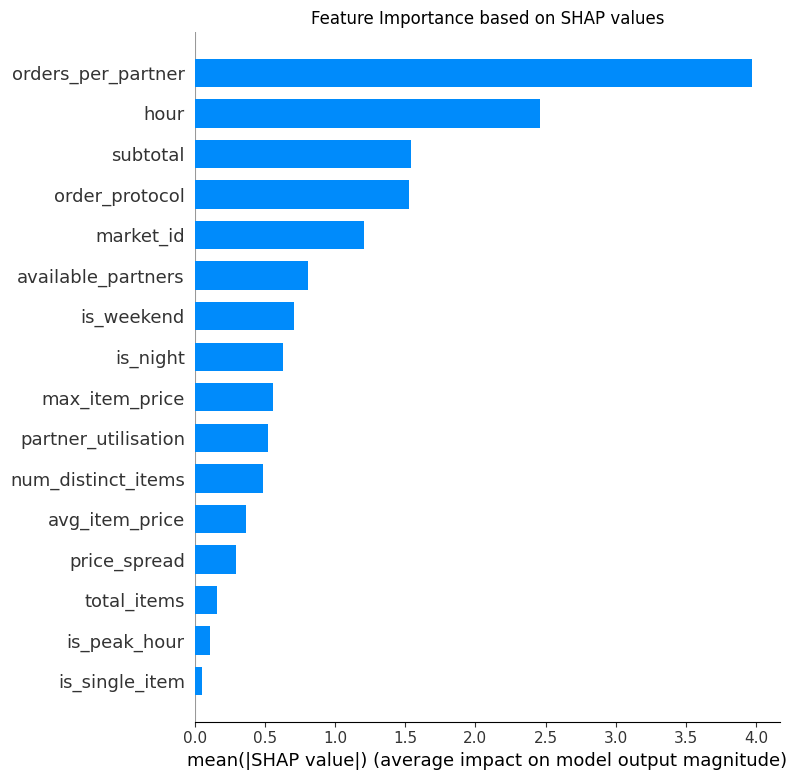

In [15]:
plt.figure(figsize=(10,7))
shap.summary_plot(
    shap_values,
    X_sample,
    plot_type="bar",
    show=False
)
plt.title("Feature Importance based on SHAP values")
plt.tight_layout()
plt.show()

shap beeswarm plot

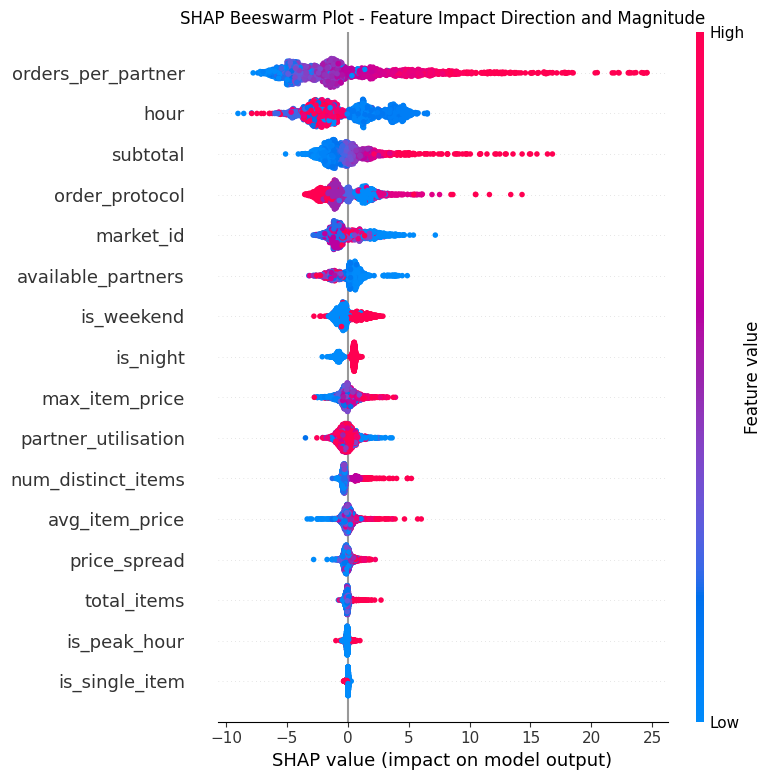

In [16]:
plt.figure(figsize=(20,16))
shap.summary_plot(
    shap_values,
    X_sample,
    plot_type="dot",
    show=False
)

plt.title("SHAP Beeswarm Plot - Feature Impact Direction and Magnitude")
plt.tight_layout()
plt.show()

In [17]:
shap_importance = pd.DataFrame(
    {
        "feature":X_sample.columns,
        "mean_abs_shap": np.abs(shap_values).mean(axis=0)
    }
).sort_values(by="mean_abs_shap", ascending=False)

print("----- SHAP Feature Importance ----- ")
print(shap_importance.to_string(index=False))

----- SHAP Feature Importance ----- 
            feature  mean_abs_shap
 orders_per_partner       3.970645
               hour       2.461174
           subtotal       1.540967
     order_protocol       1.525775
          market_id       1.205457
 available_partners       0.808437
         is_weekend       0.708357
           is_night       0.628519
     max_item_price       0.559910
partner_utilisation       0.522427
 num_distinct_items       0.486111
     avg_item_price       0.367413
       price_spread       0.294315
        total_items       0.160559
       is_peak_hour       0.110103
     is_single_item       0.049881


residual analysis

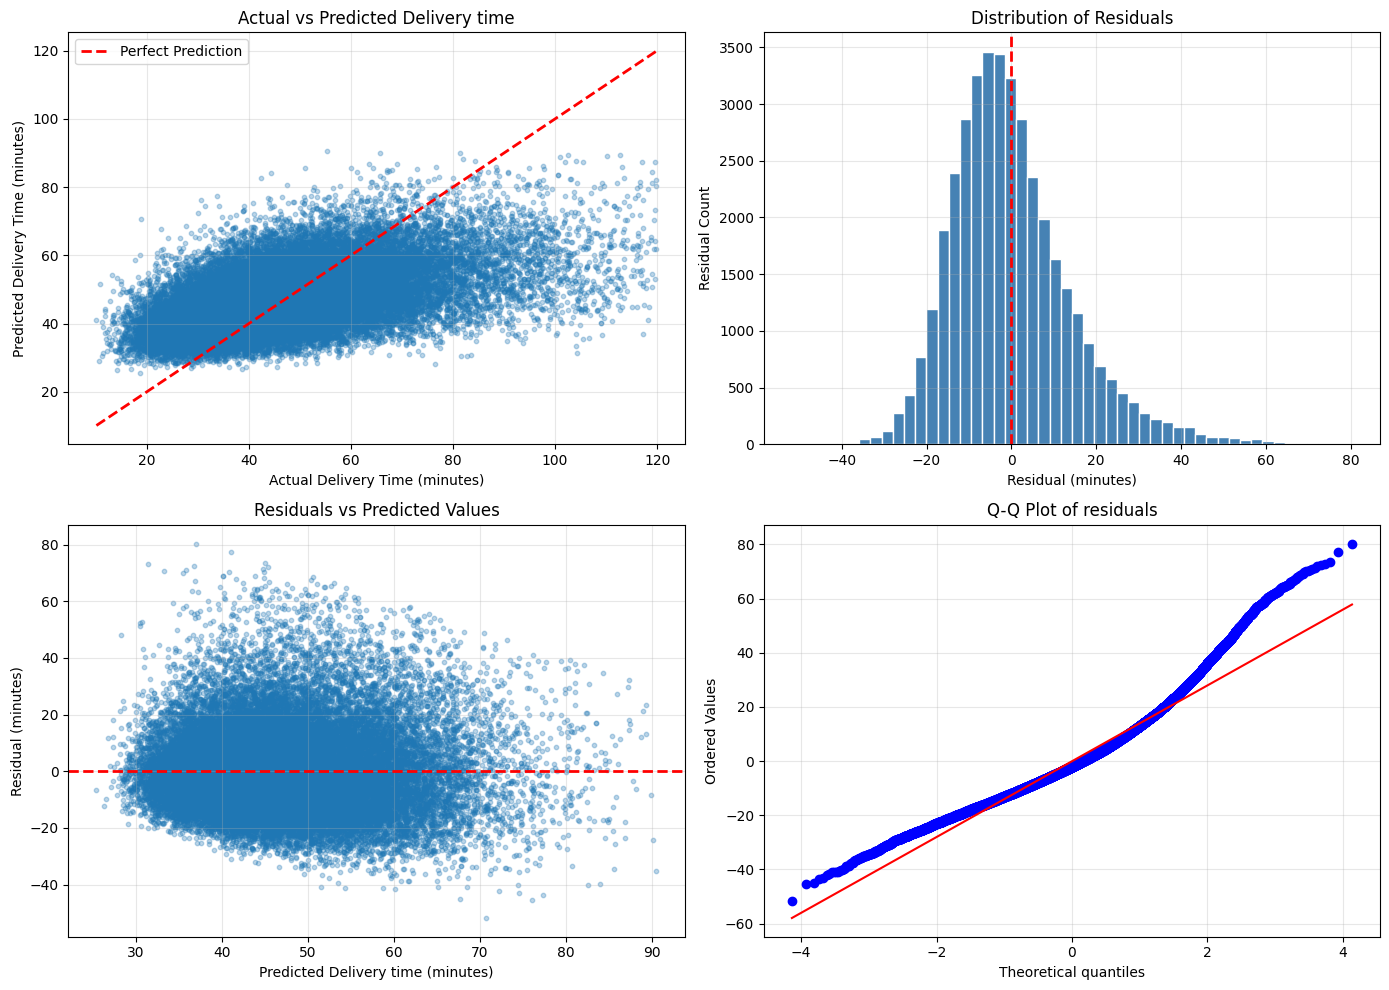

----- Residual Statistics -----
Mean: -0.04
Standard Deviation: 14.31
Min: -51.75
Max: 80.34
Predictions within ±10 minutes: 55.65%
Predictions within ±5 minutes: 30.14%


In [18]:
# calculate the residual on test set

y_pred_best = best_xgb.predict(X_test)
residuals = y_test - y_pred_best

# create 4 diagnostic plots

fig, axes = plt.subplots(2, 2, figsize=(14,10))

axes[0,0].scatter(y_test, y_pred_best,alpha=0.3, s=10)
axes[0,0].plot([y_test.min(),y_test.max()], [y_test.min(), y_test.max()],
               'r--', lw=2, label='Perfect Prediction')
axes[0,0].set_xlabel("Actual Delivery Time (minutes)")
axes[0,0].set_ylabel("Predicted Delivery Time (minutes)")
axes[0,0].set_title("Actual vs Predicted Delivery time")
axes[0,0].legend()
axes[0,0].grid(alpha=0.3)

# residuals histogram
axes[0,1].hist(residuals, bins=50, color='steelblue', edgecolor='white')
axes[0,1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0,1].set_xlabel("Residual (minutes)")
axes[0,1].set_ylabel('Residual Count')
axes[0,1].set_title("Distribution of Residuals")
axes[0,1].grid(alpha=0.3)

# Plot 3 Residuals vs Predicted
axes[1,0].scatter(y_pred_best, residuals, alpha=0.3, s=10)
axes[1,0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1,0].set_xlabel("Predicted Delivery time (minutes)")
axes[1,0].set_ylabel("Residual (minutes)")
axes[1,0].set_title("Residuals vs Predicted Values")
axes[1,0].grid(alpha=0.3)

# PLOT 4 - Q-Q Plot of residuals
from scipy import stats
stats.probplot(residuals, dist='norm', plot=axes[1,1])
axes[1,1].set_title("Q-Q Plot of residuals")
axes[1,1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("----- Residual Statistics -----")
print(f"Mean: {residuals.mean():.2f}")
print(f"Standard Deviation: {residuals.std():.2f}")
print(f"Min: {residuals.min():.2f}")
print(f"Max: {residuals.max():.2f}")
print(f"Predictions within ±10 minutes: {(residuals.abs() <= 10).mean()*100:.2f}%")
print(f"Predictions within ±5 minutes: {(residuals.abs() <= 5).mean()*100:.2f}%")


save the model

In [ ]:
import joblib
import os

os.makedirs('../models', exist_ok=True)

# save the best model
joblib.dump(best_xgb, '../models/xgboost_eta_model.pkl')

# Save features list for critical deployment
feature_list = list(X.columns)
joblib.dump(feature_list, '../models/feature_list.pkl')

print("Model and feature list saved successfully in the '../models' directory.")
print(f"models expect these {len(feature_list)} features")
for feat in feature_list:
    print(f" -> {feat}")

Model and feature list saved successfully in the '../models' directory.
models expect these 16 features
 -> market_id
 -> order_protocol
 -> total_items
 -> subtotal
 -> num_distinct_items
 -> max_item_price
 -> hour
 -> is_weekend
 -> is_peak_hour
 -> is_night
 -> partner_utilisation
 -> orders_per_partner
 -> available_partners
 -> price_spread
 -> avg_item_price
 -> is_single_item
